In [25]:
# DATA VISUALISATION — IEA Critical Minerals Dataset 2026 (South America, mining 2025–2040)
#
# Project hypothesis: rising global demand for critical minerals drives the expansion of mining in Latin America; this expansion may be linked to more
# environmental conflicts and more violence against environmental defenders, made worse by organised crime and competition for resource-rich areas.
#
# Research question: Do resource-rich countries in Latin America see more killings of environmental defenders?
#
# Role of this notebook: the IEA data covers the first link of the hypothesis — mining and its expected change. It answers three questions:
# 1. Which South American countries are resource-rich in critical minerals today (2025)?        → charts 1 and 2
# 2. Where is mining expected to expand, and where to shrink, until 2040?                       → charts 3, 4 and 5
# 3. What do the trends suggest beyond 2040, and how far can we trust them?                     → chart 6
# Chart 7 shows how the balance between producing countries shifts (copper and lithium).
# The countries and minerals where mining expands are candidate places for new conflicts; they are compared with the killings (Global Witness) and conflict events (ACLED) in the combining step, not here.
#
# File — What it contains
# iea_data_clean (1).csv — in github.com/len-chou/TeamTokio---Week-3-Project-, made by IEA_data_cleaning_nV2.ipynb (step 9).
# 288 rows = 12 South American countries × 6 minerals × 4 years (2025, 2030, 2035, 2040). Mining only (no refining), IEA base case.
#
# Know before using it (from the cleaning notebook):
# - Units: kt = kilotonnes = thousand tonnes of mineral content.
# - 2025 is the IEA's estimate for the current year; 2030, 2035 and 2040 are IEA projections (base case = mines that operate today or are already planned), not observed data.
#   So every "trend" in this notebook is a trend in the IEA's projection.
# - The IEA names only the biggest producers of each mineral. In South America these are Argentina, Brazil, Chile and Peru;
#   the other 8 countries have value 0, which means "not reported separately by the IEA", not "no mining" (e.g. Bolivia's lithium is in "Rest of world").
# - Only 6 minerals: copper, cobalt, lithium, nickel, graphite, magnet rare earths. Gold is not in the IEA data (the ICMM data covers gold).
# - Demand is not in this file (the IEA gives it for the whole world only, see the cleaning notebook, step 4). This notebook shows supply only.
#
# Every chart is saved as a PNG file in the figures/ folder, for slides or the report.

In [26]:
# 1) Importing the libraries
#
# - pandas (pd) — to read the table, filter it and make small summary tables.
# - numpy (np) — for calculations: the straight-line trends of chart 6 (np.polyfit) and positions of labels.
# - matplotlib (plt) — to draw the charts; LinearSegmentedColormap makes the colour scale of chart 4.
# - Path — to create the figures/ folder.

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [28]:
# 2) Load the clean data from GitHub
#
# What: read iea_data_clean (1).csv straight from our GitHub repo.
#
# Why: reading it from the repo means everyone in the team makes the charts from exactly the same file, with no local copies.
#
# How:
# - repo is the raw GitHub address of our repo; file_in_repo is the file name as it appears in the repo: "iea_data_clean (1).csv".
#   A space cannot be written in a web link, so it is written %20.
#   ⚠ If the file is renamed in the repo (for example to iea_data_clean.csv), change file_in_repo below.
# - pd.read_csv reads a web link directly, like a file on the computer.
#
# Output: the link that was read, the size of the table (rows, columns) and the first rows.

In [29]:
repo = "https://raw.githubusercontent.com/len-chou/TeamTokio---Week-3-Project-/refs/heads/main/"
file_in_repo = "iea_data_clean%20(1).csv"
FIG_DIR = Path("figures")          # the charts are saved here, next to this notebook
FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(repo + file_in_repo)

print("Read:", repo + file_in_repo)
print("Shape:", df.shape)
df.head()

Read: https://raw.githubusercontent.com/len-chou/TeamTokio---Week-3-Project-/refs/heads/main/iea_data_clean%20(1).csv
Shape: (288, 11)


,dataset,mineral_group,mineral,stage,country,row_type,total_label,scenario,year,value,unit
0,supply,Cobalt,Cobalt,Mining,Argentina,country,NaN,Base case,2025,0.0,kt
1,supply,Cobalt,Cobalt,Mining,Argentina,country,NaN,Base case,2030,0.0,kt
2,supply,Cobalt,Cobalt,Mining,Argentina,country,NaN,Base case,2035,0.0,kt
3,supply,Cobalt,Cobalt,Mining,Argentina,country,NaN,Base case,2040,0.0,kt
4,supply,Cobalt,Cobalt,Mining,Bolivia,country,NaN,Base case,2025,0.0,kt


In [30]:
# 3) Get to know the table before drawing anything
#
# 3A. What is in each column?
#
# What: the number of different values in each column, and the values themselves when there are only a few.
#
# Why: to know which columns are useful for charts. Some columns have the same value on every row (dataset = supply, row_type = country, scenario = Base case, unit = kt):
# they were needed in the cleaning notebook, where supply and demand were mixed, but carry no information here. total_label is empty on every row.
#
# Output: one line per column.

In [31]:
for col in df.columns:
    values = df[col].dropna().unique()
    shown = list(values) if len(values) <= 12 else list(values[:5]) + ["..."]
    print(f"{col:14} {len(values):3} different values: {shown}")

dataset          1 different values: ['supply']
mineral_group    6 different values: ['Cobalt', 'Copper', 'Graphite', 'Lithium', 'Magnet rare earths', 'Nickel']
mineral          6 different values: ['Cobalt', 'Copper', 'Graphite', 'Lithium', 'Magnet rare earth elements', 'Nickel']
stage            2 different values: ['Mining', 'Mining (natural)']
country         12 different values: ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']
row_type         1 different values: ['country']
total_label      0 different values: []
scenario         1 different values: ['Base case']
year             4 different values: [np.int64(2025), np.int64(2030), np.int64(2035), np.int64(2040)]
value           23 different values: [np.float64(0.0), np.float64(5485.0), np.float64(5369.0), np.float64(4841.0), np.float64(4165.0), '...']
unit             1 different values: ['kt']


In [32]:
# 3B. Which rows have a real number?
#
# What: the rows where value is larger than 0, as a small table (country and mineral down the side, years across).
#
# Why: 264 of the 288 rows are 0 ("not reported separately"). Only 24 rows — 6 country–mineral pairs × 4 years — carry a number.
# Every chart below is built on these 6 pairs, so it helps to see them once as plain numbers.
#
# How: df[df["value"] > 0] keeps the rows with a number; pivot_table puts the years in columns.
#
# Output: the number of rows with a value, and the 6 × 4 table in kt.

In [33]:
reported = df[df["value"] > 0].copy()
print("Rows with a value:", len(reported), "of", len(df))

reported.pivot_table(index=["country", "mineral_group", "stage"], columns="year", values="value")

Rows with a value: 24 of 288


year                                        2025    2030    2035    2040
country   mineral_group stage                                           
Argentina Lithium       Mining              18.7    51.4    54.1    54.4
Brazil    Graphite      Mining (natural)    64.1    98.5   104.0    83.9
          Nickel        Mining              85.0    82.0    82.0    82.0
Chile     Copper        Mining            5485.0  5369.0  4841.0  4165.0
          Lithium       Mining              52.1    56.6    58.4    58.6
Peru      Copper        Mining            2726.0  2712.0  2384.0  1859.0

In [34]:
# 4) Chart style, colours and helper columns
#
# What: one style and fixed colours for every chart, and a few helper columns used by several charts.
#
# How — colours:
# - Each reported country always has the same colour: Chile = blue, Peru = orange, Argentina = green, Brazil = violet.
#   These four were checked to stay distinguishable for colour-blind readers, and every chart also has labels, so colour is never the only clue.
# - A country that mines two minerals keeps its colour; its second mineral (Chile lithium, Brazil graphite) is drawn with a dashed line.
# - Chart 4 (growth or decline) uses its own scale: orange = decline, light grey = no change, blue = growth.
# - Grid lines are light grey and behind the data; the top and right frame lines are removed.
#
# How — helper columns and lists:
# - pair — a short name for each country–mineral pair, e.g. "Chile – Copper";
# - base_2025 — the 2025 value of the same pair (used for the index in chart 3);
# - index_2025 — value / base_2025 × 100 (explained in chart 3);
# - MINERALS_SA — the 4 minerals with a South American producer, from the biggest volume to the smallest;
# - DASHED — the pairs drawn with a dashed line.
#
# Output: the reported rows with the new columns.

In [35]:
COUNTRY_COLOURS = {"Chile": "#2a78d6", "Peru": "#eb6834", "Argentina": "#1baf7a", "Brazil": "#4a3aa7"}
TOTAL_COLOUR = "#8a8984"                                   # grey, for the South American total
TEXT, TEXT_SOFT, GRID, EMPTY = "#0b0b0b", "#52514e", "#e4e3df", "#f1f0ec"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TEXT_SOFT, "axes.labelcolor": TEXT_SOFT, "axes.titlecolor": TEXT,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": TEXT_SOFT, "ytick.color": TEXT_SOFT, "font.size": 10,
    "legend.frameon": False,
})

MINERALS_SA = ["Copper", "Nickel", "Graphite", "Lithium"]
YEARS = sorted(df["year"].unique())
DASHED = {"Chile – Lithium", "Brazil – Graphite"}

reported["pair"] = reported["country"] + " – " + reported["mineral_group"]
reported = reported.sort_values(["pair", "year"]).reset_index(drop=True)
reported["base_2025"] = reported.groupby("pair")["value"].transform("first")     # first year of each pair = 2025
reported["index_2025"] = reported["value"] / reported["base_2025"] * 100

def fmt(v):
    """5,485 for big values, 18.7 for small ones."""
    return f"{v:,.0f}" if abs(v) >= 100 else f"{v:.1f}"

reported[["pair", "year", "value", "base_2025", "index_2025"]].round(1)

,pair,year,value,base_2025,index_2025
0,Argentina – Lithium,2025,18.7,18.7,100.0
1,Argentina – Lithium,2030,51.4,18.7,274.9
2,Argentina – Lithium,2035,54.1,18.7,289.3
3,Argentina – Lithium,2040,54.4,18.7,290.9
4,Brazil – Graphite,2025,64.1,64.1,100.0
5,Brazil – Graphite,2030,98.5,64.1,153.7
6,Brazil – Graphite,2035,104.0,64.1,162.2
7,Brazil – Graphite,2040,83.9,64.1,130.9
8,Brazil – Nickel,2025,85.0,85.0,100.0
9,Brazil – Nickel,2030,82.0,85.0,96.5


In [36]:
# 5) Chart 1 — Which countries are resource-rich in critical minerals? (2025)
#
# What: a grid with the 12 South American countries down the side and the 6 minerals across the top. A cell is coloured (in the country's colour) when the IEA gives a number,
# pale grey when it does not; the 2025 value in kt is written in the coloured cells.
#
# Why: "resource-rich" is the first word of the research question. This chart shows which countries the IEA counts among the world's major miners of each critical mineral —
# and, just as important, how many countries it does not report separately.
#
# How:
# - pivot_table makes the 12 × 6 grid of 2025 values (0 = not reported);
# - one rectangle per cell (ax.add_patch), so each reported cell gets its country's colour. A normal heatmap would colour by size,
#   and copper (thousands of kt) would make lithium (tens of kt) invisible;
# - the 4 reported countries come first, then the others in alphabetical order.
#
# How to read it: only 6 of the 72 cells have a number. Chile (copper, lithium), Peru (copper), Argentina (lithium) and Brazil (nickel, graphite) are the resource-rich countries in the IEA data;
# no South American country is named for cobalt or magnet rare earths. ⚠ A pale cell does not mean "no mining": e.g. Bolivia's lithium and Colombia's nickel are inside "Rest of world".
#
# Output: the grid, saved as figures/iea_1_coverage.png.

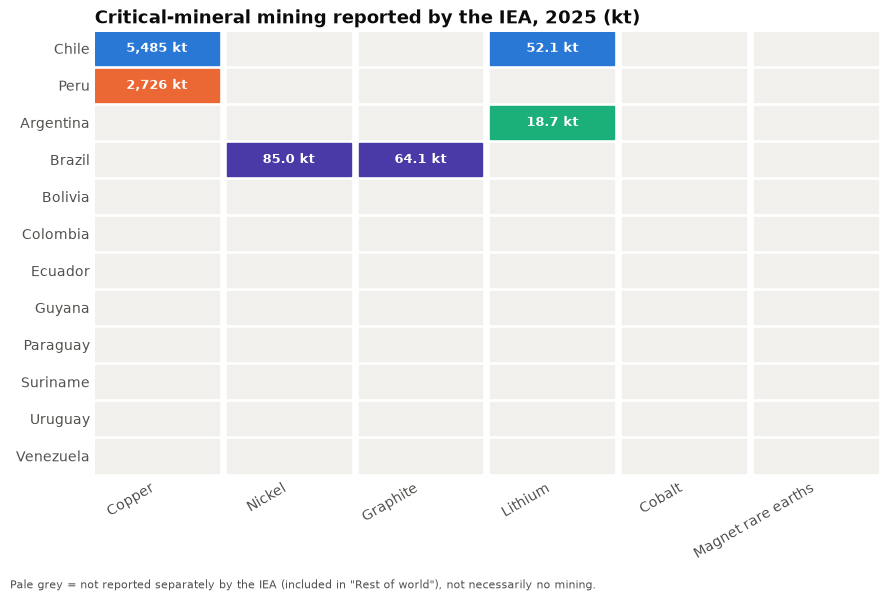

In [37]:
y2025 = df[df["year"] == 2025].pivot_table(index="country", columns="mineral_group", values="value")
col_order = ["Copper", "Nickel", "Graphite", "Lithium", "Cobalt", "Magnet rare earths"]
row_order = list(COUNTRY_COLOURS) + sorted(set(y2025.index) - set(COUNTRY_COLOURS))
y2025 = y2025.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(9, 6))
for i, country in enumerate(y2025.index):
    for j, mineral in enumerate(y2025.columns):
        v = y2025.loc[country, mineral]
        ax.add_patch(plt.Rectangle((j, i), 0.94, 0.9, color=COUNTRY_COLOURS.get(country, EMPTY) if v > 0 else EMPTY))
        if v > 0:
            ax.text(j + 0.47, i + 0.45, fmt(v) + " kt", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_xlim(0, len(col_order))
ax.set_ylim(len(row_order), 0)                     # first country at the top
ax.set_xticks(np.arange(len(col_order)) + 0.47)
ax.set_xticklabels(col_order, rotation=30, ha="right")
ax.set_yticks(np.arange(len(row_order)) + 0.45)
ax.set_yticklabels(row_order)
ax.tick_params(length=0)
ax.grid(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_visible(False)
ax.set_title("Critical-mineral mining reported by the IEA, 2025 (kt)")
fig.text(0.01, 0.01, "Pale grey = not reported separately by the IEA (included in \"Rest of world\"), not necessarily no mining.",
         color=TEXT_SOFT, fontsize=8)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / "iea_1_coverage.png", dpi=200)
plt.show()

In [38]:
# 6) Chart 2 — How much is mined, and the projected path to 2040 (kt)
#
# What: four small line charts, one per mineral with a South American producer. Each line is one country, each dot one year.
# For copper and lithium, which have two producers, a grey dashed line shows the South American total. The 2025 part of the axis is shaded "today", the rest "IEA projection".
#
# Why: it gives the real amounts in kt, and shows whether the IEA expects each country's mining to go up, down or stay flat.
#
# How:
# - One panel per mineral, each with its own vertical scale (copper is in thousands of kt, lithium in tens of kt; one scale would flatten lithium to nothing).
#   ⚠ Compare the shape of the lines within a panel, not their height between panels — chart 3 puts them on one scale.
# - pivot_table gives one column per country and one row per year; ax.plot draws one line per column;
# - the kt value is written at the start (2025) and end (2040) of each line; the axis starts at 0, so small changes do not look big;
# - ax.axvspan shades the projected years (after 2025) very lightly;
# - cobalt and magnet rare earths are left out: no South American country is reported for them.
#
# How to read it: copper is by far the largest activity, but the IEA expects it to fall from 8,211 kt to 6,024 kt (Chile and Peru both decline, mostly after 2030).
# Lithium grows from 70.8 to 113 kt, mostly because of Argentina (18.7 → 54.4 kt), and almost all of that growth happens before 2030. Brazil's graphite rises until 2035, then falls; Brazil's nickel is flat.
#
# Output: the four-panel line chart, saved as figures/iea_2_volume_per_mineral.png.

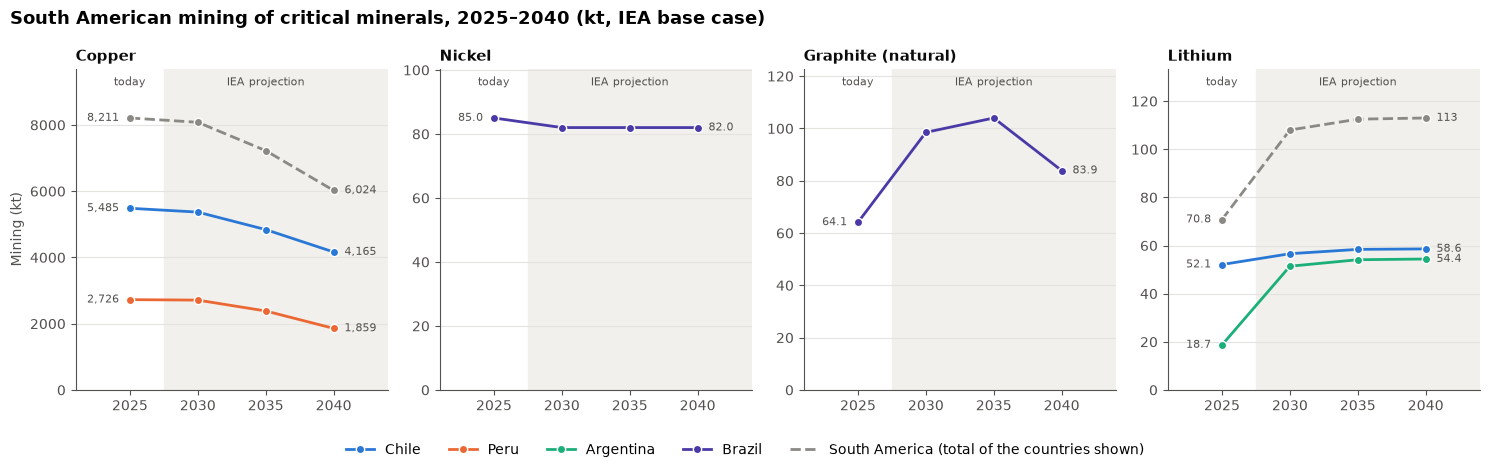

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6))
for ax, mineral in zip(axes, MINERALS_SA):
    part = reported[reported["mineral_group"] == mineral].pivot_table(index="year", columns="country", values="value")
    lines = [(country, part[country], COUNTRY_COLOURS[country], "-") for country in part.columns]
    if part.shape[1] > 1:                          # two producers: add the South American total
        lines.append(("South America", part.sum(axis=1), TOTAL_COLOUR, "--"))
    ax.axvspan(2027.5, 2044, color=EMPTY, zorder=0)
    for name, values, colour, style in lines:
        ax.plot(values.index, values.values, color=colour, linestyle=style, linewidth=2,
                marker="o", markersize=6, markeredgecolor="white", zorder=3)
        ax.text(values.index[0] - 0.8, values.iloc[0], fmt(values.iloc[0]), ha="right", va="center", fontsize=8, color=TEXT_SOFT)
        ax.text(values.index[-1] + 0.8, values.iloc[-1], fmt(values.iloc[-1]), ha="left", va="center", fontsize=8, color=TEXT_SOFT)
    top = max(v.max() for _, v, _, _ in lines)
    ax.set_ylim(0, top * 1.18)
    ax.set_xlim(2021, 2044)
    ax.set_xticks(YEARS)
    ax.text(2025, top * 1.12, "today", ha="center", fontsize=8, color=TEXT_SOFT)
    ax.text(2035, top * 1.12, "IEA projection", ha="center", fontsize=8, color=TEXT_SOFT)
    stage = reported.loc[reported["mineral_group"] == mineral, "stage"].iloc[0]
    ax.set_title(mineral + (" (natural)" if "natural" in stage else ""), fontsize=11)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Mining (kt)")

handles = [plt.Line2D([], [], color=c, linewidth=2, marker="o", markeredgecolor="white") for c in COUNTRY_COLOURS.values()]
handles.append(plt.Line2D([], [], color=TOTAL_COLOUR, linewidth=2, linestyle="--"))
fig.legend(handles, list(COUNTRY_COLOURS) + ["South America (total of the countries shown)"],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("South American mining of critical minerals, 2025–2040 (kt, IEA base case)", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.savefig(FIG_DIR / "iea_2_volume_per_mineral.png", dpi=200)
plt.show()

In [40]:
# 7) Chart 3 — Which mining grows fastest? (line chart, % change since 2025)
#
# What: one line per country–mineral pair, on one scale: the % change in mining compared with 2025, for 2025, 2030, 2035 and 2040.
# Every line starts at 0 % in 2025. Lines that go up (blue) = growth; lines that go down (orange) = decline.
# At the end of each line: its name, its % change in 2040 and the amounts in kt (2025 → 2040).
#
# Why: this is the line-chart version of chart 5. It shows the same result (where mining grows or shrinks), plus the path over time:
# whether the change happens early (before 2030) or late (after 2030).
#
# How:
# - % change since 2025 = (value − value in 2025) / value in 2025 × 100, per pair.
#   It is the index of step 4 minus 100 (index 291 = +191 %). It has no unit: kt ÷ kt, so all minerals fit on one axis,
#   even though copper is counted in thousands of kt and lithium in tens of kt.
# - colour = direction in 2040 (blue = growth, orange = decline); the dark line at 0 % = "same as 2025";
# - the end labels are spread so they do not overlap.
# ⚠ A big % can be a small amount of tonnes: that is why the kt are written in the labels.
#
# How to read it: Argentina's lithium jumps by +175 % before 2030, then stays almost flat (+191 % in 2040), from a small base (18.7 → 54.4 kt).
# Brazil's graphite rises until 2035 (+62 %) and ends at +31 %; Chile's lithium grows a little (+12 %). Copper is stable until 2030,
# then falls in both Chile (−24 %) and Peru (−32 %) — but it loses far more tonnes than lithium gains.
#
# Output: the line chart, saved as figures/iea_3_index_2025.png, then the table of % changes.

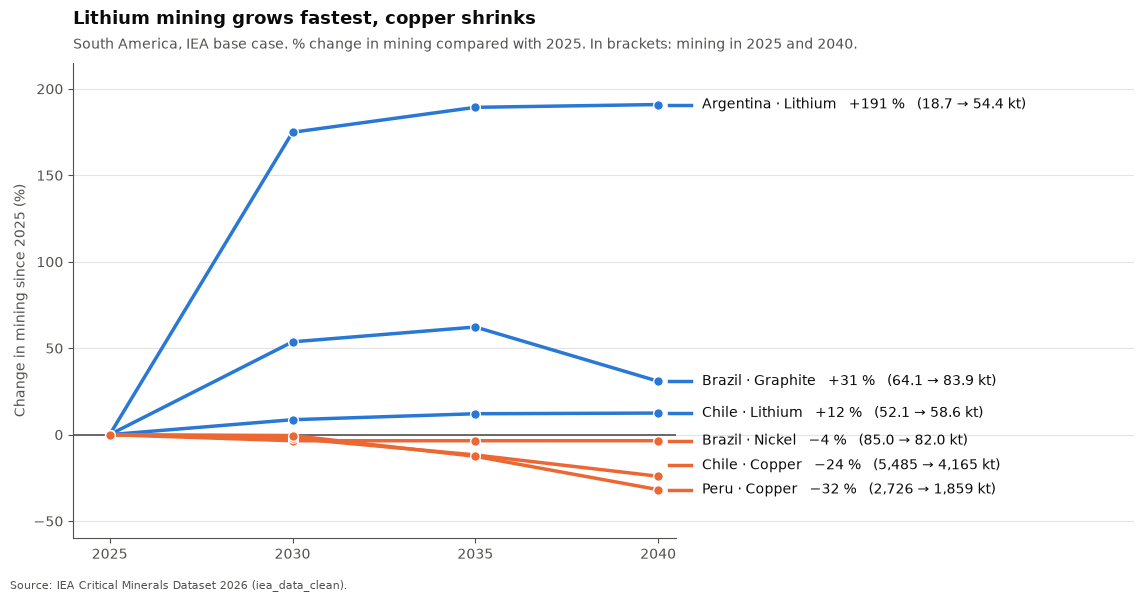

year,2025,2030,2035,2040
pair,,,,
Argentina – Lithium,0.0,175.0,189.0,191.0
Brazil – Graphite,0.0,54.0,62.0,31.0
Brazil – Nickel,0.0,-4.0,-4.0,-4.0
Chile – Copper,0.0,-2.0,-12.0,-24.0
Chile – Lithium,0.0,9.0,12.0,12.0
Peru – Copper,0.0,-1.0,-13.0,-32.0


In [41]:
UP, DOWN = "#2a78d6", "#eb6834"
reported["pct_since_2025"] = reported["index_2025"] - 100

fig, ax = plt.subplots(figsize=(11.5, 6))
ax.hlines(0, 2024, 2040.5, color=TEXT_SOFT, linewidth=1.2, zorder=1)      # the 0 % line stops before the labels
end_labels = []
for pair, part in reported.groupby("pair"):
    last = part.iloc[-1]
    colour = UP if last["pct_since_2025"] >= 0 else DOWN
    ax.plot(part["year"], part["pct_since_2025"], color=colour, linewidth=2.5,
            marker="o", markersize=7, markeredgecolor="white", zorder=3)
    text = f"{pair.replace(' – ', ' · ')}   {last['pct_since_2025']:+.0f} %   ({fmt(part['value'].iloc[0])} → {fmt(last['value'])} kt)"
    end_labels.append([last["pct_since_2025"], text.replace("-", "−"), colour])

end_labels.sort()                                    # spread the end labels: at least 14 points apart
for k in range(1, len(end_labels)):
    end_labels[k][0] = max(end_labels[k][0], end_labels[k - 1][0] + 14)
for y, text, colour in end_labels:
    ax.plot([2040.3, 2040.9], [y, y], color=colour, linewidth=2.5)
    ax.text(2041.2, y, text, va="center", fontsize=10, color=TEXT)

ax.set_xticks(YEARS)
ax.set_xlim(2024, 2053)
ax.spines["bottom"].set_bounds(2024, 2040.5)
ax.set_ylim(-60, 215)
ax.set_ylabel("Change in mining since 2025 (%)")
ax.grid(axis="x", visible=False)
ax.set_title("Lithium mining grows fastest, copper shrinks", pad=28)
ax.text(0, 1.03, "South America, IEA base case. % change in mining compared with 2025. In brackets: mining in 2025 and 2040.",
        transform=ax.transAxes, fontsize=10, color=TEXT_SOFT)
fig.text(0.01, 0.01, "Source: IEA Critical Minerals Dataset 2026 (iea_data_clean).", fontsize=8, color=TEXT_SOFT)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / "iea_3_index_2025.png", dpi=200)
plt.show()

reported.pivot_table(index="pair", columns="year", values="pct_since_2025").round(0)

In [42]:
# 8) Chart 4 — When does the change happen? (% change in each 5-year period)
#
# What: a grid with the 6 country–mineral pairs down the side and the three 5-year periods across (2025→2030, 2030→2035, 2035→2040).
# Each cell is the % change in that period; blue = growth, orange = decline, pale = almost no change.
#
# Why: for the project, timing matters. Rapid growth soon means new mines, roads and water use in the next few years — the moment when land conflicts are most likely.
# A decline later means existing mines slow down (and may push companies to look for new deposits elsewhere).
#
# How:
# - pct_change() compares each year with the previous one in the same pair (groupby("pair")), × 100 for %; the first year (2025) has nothing to compare with and is dropped;
# - the colour scale is centred on 0 (TwoSlopeNorm), so no change is always pale, whatever the size of the biggest growth;
# - the value is written in every cell.
#
# How to read it: almost all of Argentina's lithium growth (+175 %) and Brazil's graphite growth (+54 %) happens in 2025–2030: expansion is expected now, not later.
# Copper is stable until 2030 and then declines in both countries, fastest in Peru after 2035 (−22 %). Brazil's graphite turns to decline after 2035 (−19 %).
#
# Output: the grid, saved as figures/iea_4_change_per_period.png, then the table behind it.

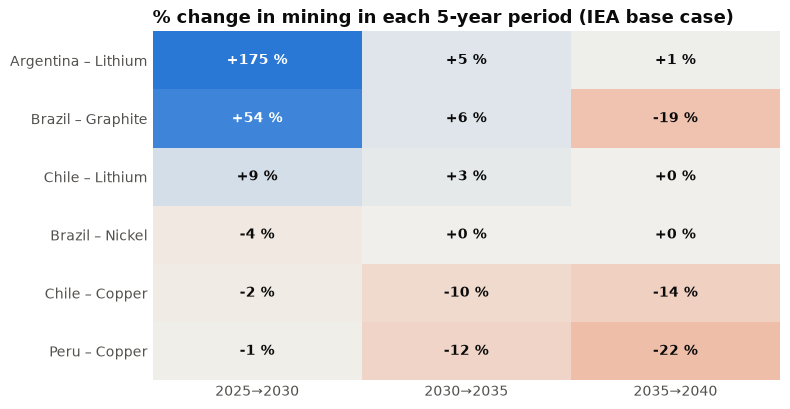

period,2025→2030,2030→2035,2035→2040
pair,,,
Argentina – Lithium,174.9,5.3,0.6
Brazil – Graphite,53.7,5.6,-19.3
Chile – Lithium,8.6,3.2,0.3
Brazil – Nickel,-3.5,0.0,0.0
Chile – Copper,-2.1,-9.8,-14.0
Peru – Copper,-0.5,-12.1,-22.0


In [43]:
reported["pct_change"] = reported.groupby("pair")["value"].pct_change() * 100
periods = reported.dropna(subset=["pct_change"]).copy()
periods["period"] = (periods["year"] - 5).astype(str) + "→" + periods["year"].astype(str)
grid = periods.pivot_table(index="pair", columns="period", values="pct_change")
grid = grid.loc[reported.groupby("pair")["index_2025"].last().sort_values(ascending=False).index]   # fastest growth at the top

cmap = LinearSegmentedColormap.from_list("decline_growth", ["#eb6834", EMPTY, "#2a78d6"])
norm = TwoSlopeNorm(vmin=-60, vcenter=0, vmax=60)      # beyond ±60 % the colour stays at its strongest

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.imshow(grid.values, cmap=cmap, norm=norm, aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.iloc[i, j]
        ax.text(j, i, f"{v:+.0f} %", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 40 else TEXT, fontweight="bold")
ax.set_xticks(range(grid.shape[1]))
ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0]))
ax.set_yticklabels(grid.index)
ax.tick_params(length=0)
ax.grid(False)
for side in ax.spines.values():
    side.set_visible(False)
ax.set_title("% change in mining in each 5-year period (IEA base case)")
plt.tight_layout()
plt.savefig(FIG_DIR / "iea_4_change_per_period.png", dpi=200)
plt.show()

grid.round(1)

In [44]:
# 9) Chart 5 — Where will mining grow or shrink by 2040?
#
# What: one horizontal bar per country–mineral pair: the change in mining from 2025 to 2040, in %.
# Bars to the right of 0 (blue) = growth, to the left (orange) = decline. Next to each bar: the amounts in kt, from 2025 to 2040.
#
# Why: it sums up question 2 of this notebook in one picture — where the IEA expects mining to expand (candidate places for new conflicts) and where it will shrink.
# The kt next to each bar are there because a big % can be a small amount of tonnes.
#
# How:
# - change_pct = (value 2040 − value 2025) / value 2025 × 100;
# - bars sorted from the biggest growth (top) to the biggest decline (bottom);
# - colour = direction only (blue = growth, orange = decline);
# - yearly_pct in the table = the average growth per year over the 15 years: ((2040 / 2025) ** (1 / 15) − 1) × 100.
#
# How to read it: Argentina's lithium grows by far the most (+191 %), but from a small base (18.7 → 54.4 kt).
# Brazil's graphite (+31 %) and Chile's lithium (+12 %) also grow. Copper shrinks in both Chile (−24 %) and Peru (−32 %),
# but it loses far more tonnes (−1,320 and −867 kt) and stays by far the largest activity in 2040.
#
# Output: the bar chart, saved as figures/iea_5_change_2025_2040.png, then the table behind it.

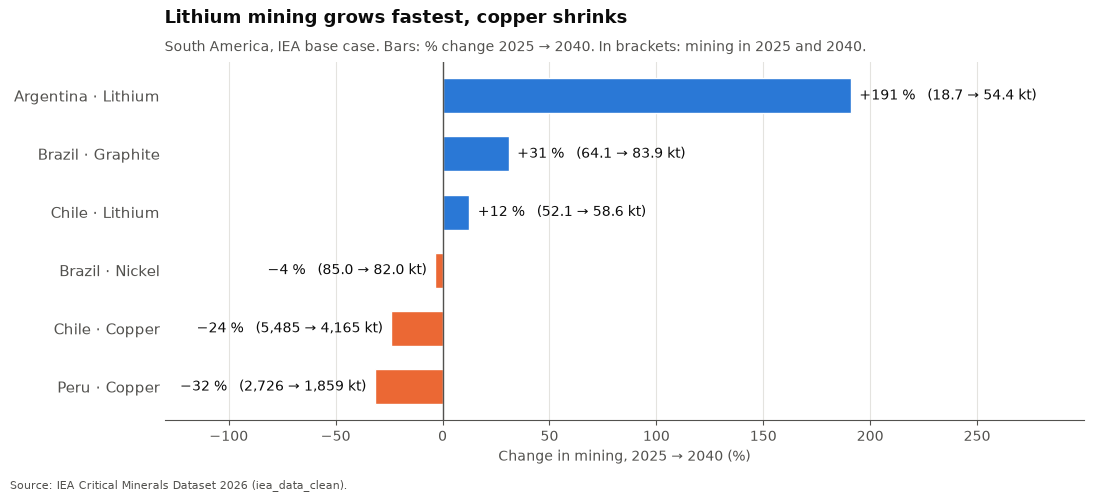

year,2025,2040,change_kt,change_pct,yearly_pct
pair,,,,,
Peru – Copper,2726.0,1859.0,-867.0,-31.8,-2.5
Chile – Copper,5485.0,4165.0,-1320.0,-24.1,-1.8
Brazil – Nickel,85.0,82.0,-3.0,-3.5,-0.2
Chile – Lithium,52.1,58.6,6.5,12.5,0.8
Brazil – Graphite,64.1,83.9,19.8,30.9,1.8
Argentina – Lithium,18.7,54.4,35.7,190.9,7.4


In [45]:
UP, DOWN = "#2a78d6", "#eb6834"

change = reported.pivot_table(index="pair", columns="year", values="value")[[2025, 2040]]
change["change_kt"] = change[2040] - change[2025]
change["change_pct"] = change["change_kt"] / change[2025] * 100
change["yearly_pct"] = ((change[2040] / change[2025]) ** (1 / 15) - 1) * 100
change = change.sort_values("change_pct")                      # biggest decline at the bottom, biggest growth at the top

fig, ax = plt.subplots(figsize=(11, 5))
colours = [UP if v >= 0 else DOWN for v in change["change_pct"]]
ax.barh(change.index, change["change_pct"], height=0.6, color=colours, edgecolor="white", zorder=3)
ax.axvline(0, color=TEXT_SOFT, linewidth=1, zorder=4)

for y, (pair, r) in enumerate(change.iterrows()):
    label = f"{r['change_pct']:+.0f} %   ({fmt(r[2025])} → {fmt(r[2040])} kt)".replace("-", "−")
    x = r["change_pct"] + 4 if r["change_pct"] >= 0 else r["change_pct"] - 4
    ax.text(x, y, label, va="center", ha="left" if r["change_pct"] >= 0 else "right", fontsize=10, color=TEXT)

ax.set_xlim(-130, 300)
ax.set_xticks([-100, -50, 0, 50, 100, 150, 200, 250])
ax.set_yticks(range(len(change)))
ax.set_yticklabels(change.index.str.replace(" – ", " · "), fontsize=11)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.set_xlabel("Change in mining, 2025 → 2040 (%)")
ax.set_title("Lithium mining grows fastest, copper shrinks", pad=28)
ax.text(0, 1.03, "South America, IEA base case. Bars: % change 2025 → 2040. In brackets: mining in 2025 and 2040.",
        transform=ax.transAxes, fontsize=10, color=TEXT_SOFT)
fig.text(0.01, 0.01, "Source: IEA Critical Minerals Dataset 2026 (iea_data_clean).", fontsize=8, color=TEXT_SOFT)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / "iea_5_change_2025_2040.png", dpi=200)
plt.show()

change.round(1)

In [46]:
# 10) Chart 6 — Trend prediction: what if the trend continued after 2040?
#
# What: six small charts, one per country–mineral pair. The dots are the IEA values (2025–2040). The solid line is the straight-line trend through them;
# the dotted part continues that line to 2050 — a simple "if nothing changes" prediction. Each panel gives the trend in kt per year and how well the line fits (R²).
#
# Why: the IEA stops at 2040. A trend line is the simplest way to see where each series is heading, and it shows which series have a clear direction and which do not.
#
# How:
# - np.polyfit(years, values, 1) finds the straight line (value = slope × year + intercept) that passes as close as possible to the 4 dots ("least squares");
#   the slope is the average change in kt per year;
# - np.polyval uses the line to compute values for 2025–2050; after 2040 it is drawn dotted, because it is our extrapolation, not IEA data;
# - R² (between 0 and 1) says how well a straight line describes the dots: close to 1 = the dots lie on a line; low = they do not (e.g. growth that stops, or a rise then a fall);
#   ⚠ when R² is low, the dotted part is not meaningful and the panel says so; a series that hardly moves (less than 5 % change in 15 years) is marked "almost flat" instead,
#   because R² is always low for a flat series and says nothing there;
# - values below 0 are cut at 0 (mining cannot be negative).
#
# ⚠ Limits of this prediction — read before using it:
# - it continues a projection, not observed data: it inherits all the IEA assumptions (base case = existing and planned mines only);
# - a straight line ignores new discoveries, new mines, prices and policies — the very things that would follow a rise in demand;
# - with only 4 points, one unusual year changes the line a lot. Use it to describe direction, not to give numbers for 2050.
#
# How to read it: copper has a clear downward trend in both countries (R² about 0.9): about −90 kt per year in Chile and −60 kt per year in Peru; continued to 2050, the two would mine
# about 3,400 and 1,400 kt. Chile's lithium has a gentle upward trend. Argentina's lithium does not follow a straight line (fast rise, then flat), so its line overstates growth after 2040;
# Brazil's graphite (rise then fall) and nickel (flat) have no clear trend.
#
# Output: the six-panel chart, saved as figures/iea_6_trend_to_2050.png, then a table with the slope, R² and the trend value for 2050.

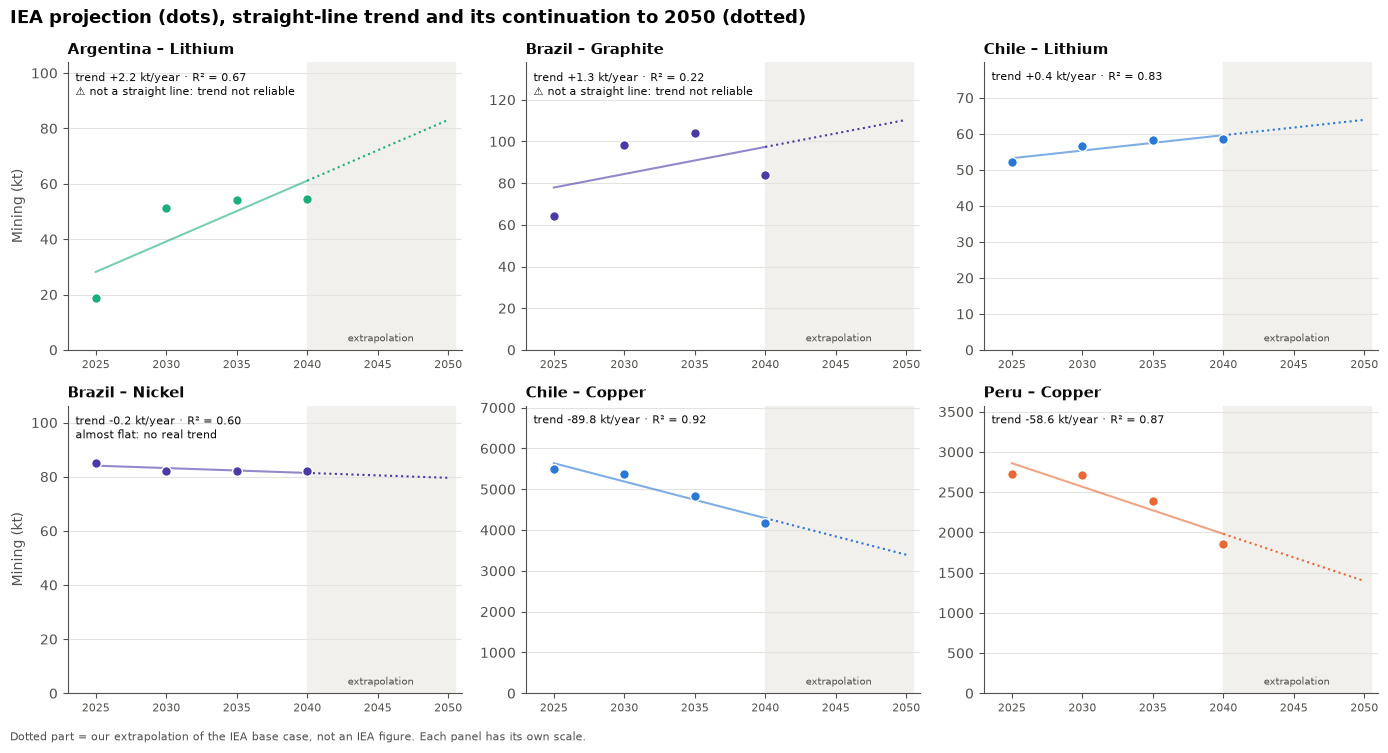

,kt_2025,kt_2040,trend_kt_per_year,r2,trend_2050_kt
pair,,,,,
Argentina – Lithium,18.7,54.4,2.20,0.67,83.08
Brazil – Graphite,64.1,83.9,1.30,0.22,110.34
Chile – Lithium,52.1,58.6,0.43,0.83,63.88
Brazil – Nickel,85.0,82.0,-0.18,0.60,79.60
Chile – Copper,5485.0,4165.0,-89.76,0.92,3394.20
Peru – Copper,2726.0,1859.0,-58.58,0.87,1395.10


In [47]:
future = np.arange(2025, 2051)
trend_rows = []
order = change.index[::-1]                                  # same order as chart 5: biggest expansion first

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, pair in zip(axes.flat, order):
    part = reported[reported["pair"] == pair]
    colour = COUNTRY_COLOURS[part["country"].iloc[0]]
    slope, intercept = np.polyfit(part["year"], part["value"], 1)
    fitted = np.polyval([slope, intercept], part["year"])
    r2 = 1 - ((part["value"] - fitted) ** 2).sum() / ((part["value"] - part["value"].mean()) ** 2).sum()
    line = np.clip(np.polyval([slope, intercept], future), 0, None)

    ax.axvspan(2040, 2050.5, color=EMPTY, zorder=0)
    ax.plot(future[future <= 2040], line[future <= 2040], color=colour, linewidth=1.5, alpha=0.6)
    ax.plot(future[future >= 2040], line[future >= 2040], color=colour, linewidth=1.5, linestyle=":")
    ax.plot(part["year"], part["value"], "o", color=colour, markersize=7, markeredgecolor="white", zorder=3)
    ax.set_ylim(0, max(part["value"].max(), line.max()) * 1.25)
    ax.set_xlim(2023, 2051)
    ax.set_xticks([2025, 2030, 2035, 2040, 2045, 2050])
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", visible=False)
    ax.set_title(pair, fontsize=11)
    note = f"trend {'+' if slope > 0 else ''}{fmt(slope)} kt/year · R² = {r2:.2f}"
    if abs(part["value"].iloc[-1] / part["value"].iloc[0] - 1) < 0.05:
        note += "\nalmost flat: no real trend"
    elif r2 < 0.7:
        note += "\n⚠ not a straight line: trend not reliable"
    ax.text(0.02, 0.97, note, transform=ax.transAxes, va="top", fontsize=8, color=TEXT)
    ax.text(2045.2, ax.get_ylim()[1] * 0.03, "extrapolation", ha="center", fontsize=7, color=TEXT_SOFT)
    trend_rows.append({"pair": pair, "kt_2025": part["value"].iloc[0], "kt_2040": part["value"].iloc[-1],
                       "trend_kt_per_year": slope, "r2": r2, "trend_2050_kt": line[-1]})
for ax in axes[:, 0]:
    ax.set_ylabel("Mining (kt)")
fig.suptitle("IEA projection (dots), straight-line trend and its continuation to 2050 (dotted)", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.text(0.01, 0.005, "Dotted part = our extrapolation of the IEA base case, not an IEA figure. Each panel has its own scale.", color=TEXT_SOFT, fontsize=8)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig(FIG_DIR / "iea_6_trend_to_2050.png", dpi=200)
plt.show()

pd.DataFrame(trend_rows).set_index("pair").round(2)

In [48]:
# 11) Chart 7 — Is the balance between producing countries shifting? (copper and lithium)
#
# What: for copper and lithium (the two minerals with two South American producers), one bar per year that always reaches 100 %, split by country.
#
# Why: a shift in the balance shows where new mining activity concentrates in the region — here, where lithium mining is growing.
#
# How:
# - share of a country = its kt / total of the reported countries for that mineral and year × 100 (groupby(...).transform("sum") gives the total on every row);
# - the share is written inside each part of the bar; 2025 is at the top.
# - ⚠ "Total" here means the countries the IEA names (Chile, Peru, Argentina); lithium from Bolivia is not in it.
#
# How to read it: Chile keeps about two thirds of the reported copper (67 % → 69 %), so the copper balance does not change.
# For lithium it does: Chile has 74 % in 2025, but from 2030 Argentina and Chile are almost equal (48 % / 52 %) — Argentina becomes a major lithium producer within five years.
#
# Output: the two-panel chart, saved as figures/iea_7_share_copper_lithium.png.

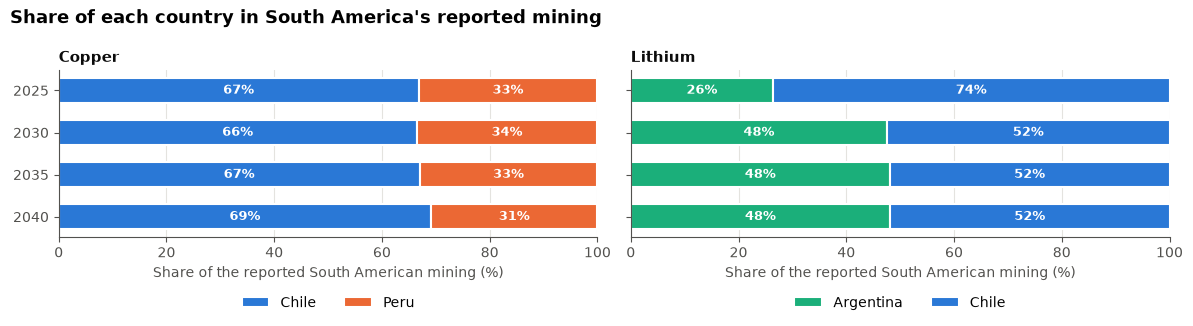

In [49]:
two = reported[reported["mineral_group"].isin(["Copper", "Lithium"])].copy()
two["share_sa"] = two["value"] / two.groupby(["mineral_group", "year"])["value"].transform("sum") * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, mineral in zip(axes, ["Copper", "Lithium"]):
    part = two[two["mineral_group"] == mineral].pivot_table(index="year", columns="country", values="share_sa")
    left = np.zeros(len(part))
    for country in part.columns:
        ax.barh(part.index.astype(str), part[country], left=left, height=0.6, color=COUNTRY_COLOURS[country],
                edgecolor="white", linewidth=1.5, label=country)
        for y, (l, v) in enumerate(zip(left, part[country])):
            ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        left += part[country].values
    ax.set_xlim(0, 100)
    ax.set_title(mineral, fontsize=11)
    ax.set_xlabel("Share of the reported South American mining (%)")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)
axes[0].invert_yaxis()                                 # 2025 at the top (once: both panels share the axis)
fig.suptitle("Share of each country in South America's reported mining", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "iea_7_share_copper_lithium.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
# 12) Summary — what the IEA data says for the project
#
# 1. Resource-rich countries (2025): the IEA names four South American countries as major critical-mineral miners — Chile (copper 5,485 kt, lithium 52 kt), Peru (copper 2,726 kt),
#    Brazil (nickel 85 kt, graphite 64 kt) and Argentina (lithium 19 kt). These are the countries to compare with the killings of defenders.
# 2. Expansion vs decline (to 2040):
#    - Expanding: Argentina's lithium (+191 %, almost all by 2030), Brazil's graphite (+31 %, then falling after 2035), Chile's lithium (+12 %).
#      → Following the hypothesis, the areas where these mines are (Argentina's lithium provinces, Brazil's graphite regions) are candidate places for new land and water conflicts, soon.
#    - Declining: copper in Chile (−24 %) and Peru (−32 %), mostly after 2030, in the base case (existing and planned mines only).
#      Copper is still by far the largest activity in 2040 (6,024 kt), and a declining supply while world demand grows can push companies to open new copper projects not yet in the base case.
# 3. Trend prediction: only copper (down) and Chile's lithium (up) follow a clear straight-line trend. Argentina's lithium is a jump followed by a plateau, so simple extrapolation overstates it.
#
# What this data can and cannot show
# - It can show: which countries the IEA counts as major miners of 6 critical minerals, and the IEA's projected path of their mining to 2040.
# - It cannot show: mining in the other 8 countries (0 = not reported separately); gold (not in the IEA data — use ICMM); where inside a country the mines are (national totals only — use ICMM for locations);
#   world demand (not in this file); and any causal link with conflict or killings — that is tested later, by combining with Global Witness and ACLED.
# - Everything after 2025 is a projection (IEA) or an extrapolation of a projection (chart 6, dotted).
#
# Files saved in figures/: iea_1_coverage.png, iea_2_volume_per_mineral.png, iea_3_index_2025.png, iea_4_change_per_period.png,
# iea_5_change_2025_2040.png, iea_6_trend_to_2050.png, iea_7_share_copper_lithium.png.